## Experiment 3: Meta-Characteristics Significance

How the selected meta-characteristics affect ID/OOD classification quality in the ensemble-of-partitions framework.

Goal: estimate meta-characteristic significance from `DecisionTreeClassifier.feature_importances_`


### Methodology

For each dataset we now evaluate meta-characteristics **by taxonomy groups** instead of ranking individual features.

1. **Taxonomy split**: divide `META_FEATURES` into groups from `metacharacteristics_taxonomy_light.md`.
2. **Group-wise evaluation**: run the OOD experiment separately for each group and compare it against the full meta-feature set.
3. **Comparison outputs**: summarize group quality in a table and visualize the group comparison with a `barchart`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from partition_ood import (
    load_dataset,
    cross_validate_ood_classifiers,
    ALL_META_FEATURES,
)

sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
CV_FOLDS = 5
BALANCE_STRATEGY = 'oversample'
INCLUDE_MLP = True
PARTITION_PARAMS = {
    'n_bins': 10,
    'n_kmeans_clusters': 10,
    'n_tree_partitions': 5,
    'tree_max_depth': 3,
    'partition_fit_data': 'id',
}

META_FEATURES = [
    'dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood',
    'local_outlier_factor_score', 'knn_distance_k',
    'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm',
    'iqr_norm', 'trimmed_mean_norm',
    'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std',
    'marginal_kl_to_reference_mean', 'quantile_surprisal_mean',
    'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation',
    'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs',
    'covariance_condition_number',
    'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation',
    'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean',
    'log_count', 'density', 'out_of_range_count', 'n_beyond_2std',
    'partition_agreement_count', 'leaf_depth',
]

META_FEATURE_GROUPS = {
    'Point-based': [
        'dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood',
        'local_outlier_factor_score', 'knn_distance_k', 'out_of_range_count',
    ],
    'Sample-based / Marginal-char / Statistical': [
        'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm',
        'iqr_norm', 'trimmed_mean_norm',
    ],
    'Sample-based / Marginal-char / Informational': [
        'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std',
        'marginal_kl_to_reference_mean', 'quantile_surprisal_mean',
    ],
    'Sample-based / Feature-interaction / Statistical': [
        'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation',
        'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs',
        'covariance_condition_number',
    ],
    'Sample-based / Feature-interaction / Informational': [
        'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation',
        'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean',
    ],
    'Base': [
        'log_count', 'density', 'n_beyond_2std', 'partition_agreement_count', 'leaf_depth',
    ],
}
GROUP_ORDER = ['All meta-features', *META_FEATURE_GROUPS.keys()]

META_FEATURES

['dist_to_mean',
 'normalized_dist',
 'cosine_dist',
 'dist_to_median',
 'log_likelihood',
 'local_outlier_factor_score',
 'knn_distance_k',
 'mean_norm',
 'std_norm',
 'skew_norm',
 'kurtosis_norm',
 'median_abs_deviation_norm',
 'iqr_norm',
 'trimmed_mean_norm',
 'cell_entropy',
 'marginal_entropy_mean',
 'marginal_entropy_std',
 'marginal_kl_to_reference_mean',
 'quantile_surprisal_mean',
 'mahalanobis',
 'covariance_trace',
 'covariance_logdet',
 'mean_abs_correlation',
 'pairwise_pearson_corr_mean_abs',
 'pairwise_spearman_corr_mean_abs',
 'covariance_condition_number',
 'pairwise_mutual_info_mean',
 'pairwise_mutual_info_max',
 'total_correlation',
 'joint_entropy_pairwise_mean',
 'pairwise_js_divergence_mean',
 'log_count',
 'density',
 'out_of_range_count',
 'n_beyond_2std',
 'partition_agreement_count',
 'leaf_depth']

In [2]:
def evaluate_subset(ID_data, OOD_data, dataset_name, group_name, experiment_type, meta_subset):
    fold_metrics, summary_df, _ = cross_validate_ood_classifiers(
        ID_data=ID_data,
        OOD_data=OOD_data,
        n_splits=CV_FOLDS,
        random_state=RANDOM_STATE,
        meta_features=meta_subset,
        use_raw_features=False,
        partition_fit_data=PARTITION_PARAMS['partition_fit_data'],
        n_bins=PARTITION_PARAMS['n_bins'],
        n_kmeans_clusters=PARTITION_PARAMS['n_kmeans_clusters'],
        n_tree_partitions=PARTITION_PARAMS['n_tree_partitions'],
        tree_max_depth=PARTITION_PARAMS['tree_max_depth'],
        balance_strategy=BALANCE_STRATEGY,
        include_mlp=INCLUDE_MLP,
    )

    rows = []
    for _, row in summary_df.iterrows():
        rows.append(
            {
                'dataset': dataset_name,
                'experiment_type': experiment_type,
                'group_name': group_name,
                'n_meta_features': len(meta_subset),
                'classifier': row['model'],
                'roc_auc': float(row['roc_auc_mean']),
                'pr_auc': float(row['pr_auc_mean']),
                'accuracy': float(row['accuracy_mean']),
                'precision': float(row['precision_mean']),
                'recall': float(row['recall_mean']),
                'f1': float(row['f1_mean']),
                'meta_subset': tuple(meta_subset),
            }
        )
    return rows


def build_meta_feature_groups(meta_features):
    base_meta_features = list(meta_features)
    unknown = sorted(set(base_meta_features) - set(ALL_META_FEATURES))
    if unknown:
        raise ValueError(f'Unknown META_FEATURES: {unknown}')
    if len(base_meta_features) == 0:
        raise ValueError('META_FEATURES must contain at least one meta-feature')

    groups = {}
    assigned = []
    for group_name, group_features in META_FEATURE_GROUPS.items():
        subset = [feature for feature in group_features if feature in base_meta_features]
        if subset:
            groups[group_name] = subset
            assigned.extend(subset)

    missing = [feature for feature in base_meta_features if feature not in assigned]
    if missing:
        raise ValueError(f'META_FEATURES are missing from taxonomy groups: {missing}')

    return groups


def run_meta_significance_experiment(dataset_name):
    ID_data, OOD_data = load_dataset(dataset_name)
    base_meta_features = list(META_FEATURES)
    taxonomy_groups = build_meta_feature_groups(base_meta_features)

    all_rows = []
    all_rows.extend(
        evaluate_subset(
            ID_data,
            OOD_data,
            dataset_name,
            group_name='All meta-features',
            experiment_type='reference',
            meta_subset=base_meta_features,
        )
    )

    for group_name, group_features in taxonomy_groups.items():
        all_rows.extend(
            evaluate_subset(
                ID_data,
                OOD_data,
                dataset_name,
                group_name=group_name,
                experiment_type='group',
                meta_subset=group_features,
            )
        )

    return pd.DataFrame(all_rows)


def build_group_comparison_view(results_df):
    comparison = (
        results_df[results_df['experiment_type'].isin(['reference', 'group'])]
        [['group_name', 'n_meta_features', 'classifier', 'roc_auc', 'pr_auc', 'f1']]
        .copy()
    )
    active_order = [group for group in GROUP_ORDER if group in comparison['group_name'].unique()]
    comparison['group_name'] = pd.Categorical(
        comparison['group_name'],
        categories=active_order,
        ordered=True,
    )
    comparison = comparison.sort_values(['group_name', 'classifier']).reset_index(drop=True)
    return comparison


def build_group_metric_table(group_comparison_df):
    metric_table = group_comparison_df.pivot_table(
        index=['group_name', 'n_meta_features'],
        columns='classifier',
        values=['roc_auc', 'pr_auc', 'f1'],
    )
    metric_table.columns = [f'{metric} | {classifier}' for metric, classifier in metric_table.columns]
    return metric_table.reset_index()


def plot_dataset_results(dataset_name, group_comparison_df):
    plot_df = group_comparison_df.copy()
    plot_df['group_name'] = plot_df['group_name'].astype(str)

    plt.figure(figsize=(16, 6))
    sns.barplot(data=plot_df, x='group_name', y='roc_auc', hue='classifier')
    plt.title(f'{dataset_name}: ROC-AUC by meta-feature group')
    plt.xlabel('Meta-feature group')
    plt.ylabel('ROC-AUC')
    plt.xticks(rotation=25, ha='right')
    plt.legend(title='Classifier', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def show_dataset_summary(dataset_name, results_df, group_comparison_df, group_metric_table):
    print(f'Dataset: {dataset_name}')

    display(group_comparison_df.round(4))
    display(group_metric_table.round(4))

    plot_dataset_results(dataset_name, group_comparison_df)


In [3]:
def evaluate_subset(ID_data, OOD_data, dataset_name, group_name, experiment_type, meta_subset):
    fold_metrics, summary_df, _ = cross_validate_ood_classifiers(
        ID_data=ID_data,
        OOD_data=OOD_data,
        n_splits=CV_FOLDS,
        random_state=RANDOM_STATE,
        meta_features=meta_subset,
        use_raw_features=False,
        partition_fit_data=PARTITION_PARAMS['partition_fit_data'],
        n_bins=PARTITION_PARAMS['n_bins'],
        n_kmeans_clusters=PARTITION_PARAMS['n_kmeans_clusters'],
        n_tree_partitions=PARTITION_PARAMS['n_tree_partitions'],
        tree_max_depth=PARTITION_PARAMS['tree_max_depth'],
        balance_strategy=BALANCE_STRATEGY,
        include_mlp=INCLUDE_MLP,
    )

    rows = []
    for _, row in summary_df.iterrows():
        rows.append(
            {
                'dataset': dataset_name,
                'experiment_type': experiment_type,
                'group_name': group_name,
                'n_meta_features': len(meta_subset),
                'classifier': row['model'],
                'roc_auc': float(row['roc_auc_mean']),
                'pr_auc': float(row['pr_auc_mean']),
                'accuracy': float(row['accuracy_mean']),
                'precision': float(row['precision_mean']),
                'recall': float(row['recall_mean']),
                'f1': float(row['f1_mean']),
                'meta_subset': tuple(meta_subset),
            }
        )
    return rows


def build_meta_feature_groups(meta_features):
    base_meta_features = list(meta_features)
    unknown = sorted(set(base_meta_features) - set(ALL_META_FEATURES))
    if unknown:
        raise ValueError(f'Unknown META_FEATURES: {unknown}')
    if len(base_meta_features) == 0:
        raise ValueError('META_FEATURES must contain at least one meta-feature')

    groups = {}
    assigned = []
    for group_name, group_features in META_FEATURE_GROUPS.items():
        subset = [feature for feature in group_features if feature in base_meta_features]
        if subset:
            groups[group_name] = subset
            assigned.extend(subset)

    missing = [feature for feature in base_meta_features if feature not in assigned]
    if missing:
        raise ValueError(f'META_FEATURES are missing from taxonomy groups: {missing}')

    return groups


def run_meta_significance_experiment(dataset_name):
    ID_data, OOD_data = load_dataset(dataset_name)
    base_meta_features = list(META_FEATURES)
    taxonomy_groups = build_meta_feature_groups(base_meta_features)

    all_rows = []
    all_rows.extend(
        evaluate_subset(
            ID_data,
            OOD_data,
            dataset_name,
            group_name='All meta-features',
            experiment_type='reference',
            meta_subset=base_meta_features,
        )
    )

    for group_name, group_features in taxonomy_groups.items():
        all_rows.extend(
            evaluate_subset(
                ID_data,
                OOD_data,
                dataset_name,
                group_name=group_name,
                experiment_type='group',
                meta_subset=group_features,
            )
        )

    return pd.DataFrame(all_rows)


def build_group_comparison_view(results_df):
    comparison = (
        results_df[results_df['experiment_type'].isin(['reference', 'group'])]
        [['group_name', 'n_meta_features', 'classifier', 'roc_auc', 'pr_auc', 'f1']]
        .copy()
    )
    active_order = [group for group in GROUP_ORDER if group in comparison['group_name'].unique()]
    comparison['group_name'] = pd.Categorical(
        comparison['group_name'],
        categories=active_order,
        ordered=True,
    )
    comparison = comparison.sort_values(['group_name', 'classifier']).reset_index(drop=True)
    return comparison


def build_group_metric_table(group_comparison_df):
    metric_table = group_comparison_df.pivot_table(
        index=['group_name', 'n_meta_features'],
        columns='classifier',
        values=['roc_auc', 'pr_auc', 'f1'],
    )
    metric_table.columns = [f'{metric} | {classifier}' for metric, classifier in metric_table.columns]
    return metric_table.reset_index()


def plot_dataset_results(dataset_name, group_comparison_df):
    plot_df = group_comparison_df.copy()
    plot_df['group_name'] = plot_df['group_name'].astype(str)

    plt.figure(figsize=(16, 6))
    sns.barplot(data=plot_df, x='group_name', y='roc_auc', hue='classifier')
    plt.title(f'{dataset_name}: ROC-AUC by meta-feature group')
    plt.xlabel('Meta-feature group')
    plt.ylabel('ROC-AUC')
    plt.xticks(rotation=25, ha='right')
    plt.legend(title='Classifier', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def show_dataset_summary(dataset_name, results_df, group_comparison_df, group_metric_table):
    print(f'Dataset: {dataset_name}')

    display(group_comparison_df.round(4))
    display(group_metric_table.round(4))

    plot_dataset_results(dataset_name, group_comparison_df)

## Taxi Data

Dataset: Taxi


,group_name,n_meta_features,classifier,roc_auc,pr_auc,f1
0,All meta-features,37,Logistic Regression,0.9981,0.9970,0.9922
1,All meta-features,37,MLP,0.9973,0.9963,0.9834
2,All meta-features,37,Random Forest,0.9959,0.9955,0.9778
3,Point-based,8,Logistic Regression,0.9970,0.9958,0.9857
4,Point-based,8,MLP,0.9972,0.9953,0.9853
5,Point-based,8,Random Forest,0.9961,0.9952,0.9828
6,Sample-based / Marginal-char / Statistical,7,Logistic Regression,0.7673,0.7639,0.6955
7,Sample-based / Marginal-char / Statistical,7,MLP,0.7297,0.7333,0.6601
8,Sample-based / Marginal-char / Statistical,7,Random Forest,0.7549,0.7466,0.6853
9,Sample-based / Marginal-char / Informational,5,Logistic Regression,0.7437,0.7395,0.6791


,group_name,n_meta_features,f1 | Logistic Regression,f1 | MLP,f1 | Random Forest,pr_auc | Logistic Regression,pr_auc | MLP,pr_auc | Random Forest,roc_auc | Logistic Regression,roc_auc | MLP,roc_auc | Random Forest
0,All meta-features,37,0.9922,0.9834,0.9778,0.9970,0.9963,0.9955,0.9981,0.9973,0.9959
1,Point-based,8,0.9857,0.9853,0.9828,0.9958,0.9953,0.9952,0.9970,0.9972,0.9961
2,Sample-based / Marginal-char / Statistical,7,0.6955,0.6601,0.6853,0.7639,0.7333,0.7466,0.7673,0.7297,0.7549
3,Sample-based / Marginal-char / Informational,5,0.6791,0.6452,0.6878,0.7395,0.7156,0.7522,0.7437,0.7146,0.7568
4,Sample-based / Feature-interaction / Statistical,7,0.7450,0.8327,0.8160,0.8364,0.9226,0.9006,0.8340,0.9190,0.9015
5,Sample-based / Feature-interaction / Informati...,5,0.6594,0.6659,0.6820,0.7413,0.7246,0.7508,0.7374,0.7240,0.7560
6,Base,5,0.6922,0.7413,0.7591,0.8093,0.8606,0.8451,0.7932,0.8306,0.8368


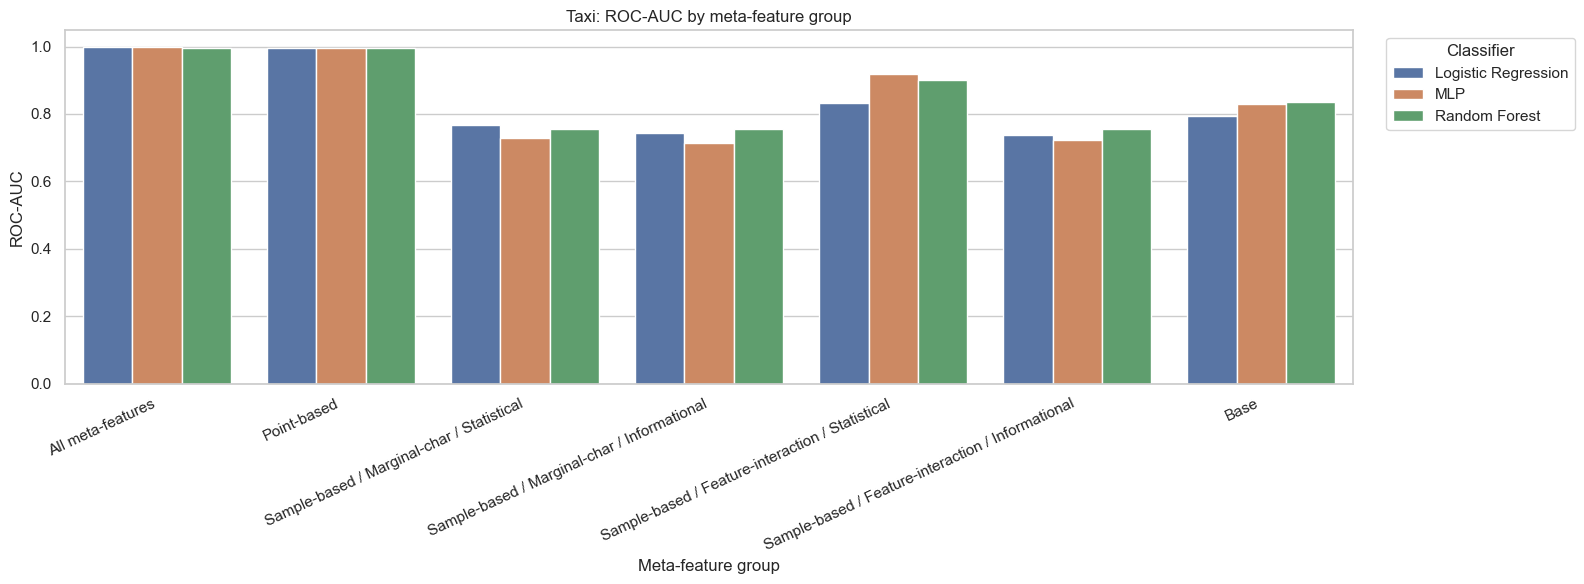

In [5]:
results_taxi = run_meta_significance_experiment('Taxi')
group_comparison_taxi = build_group_comparison_view(results_taxi)
group_table_taxi = build_group_metric_table(group_comparison_taxi)
show_dataset_summary('Taxi', results_taxi, group_comparison_taxi, group_table_taxi)


## Electricity Data

Dataset: Electricity


,group_name,n_meta_features,classifier,roc_auc,pr_auc,f1
0,All meta-features,37,Logistic Regression,0.9700,0.9622,0.9140
1,All meta-features,37,MLP,0.9705,0.9627,0.9178
2,All meta-features,37,Random Forest,0.9764,0.9711,0.9213
3,Point-based,8,Logistic Regression,0.9667,0.9586,0.9095
4,Point-based,8,MLP,0.9656,0.9551,0.9149
5,Point-based,8,Random Forest,0.9738,0.9682,0.9178
6,Sample-based / Marginal-char / Statistical,7,Logistic Regression,0.9384,0.9210,0.8802
7,Sample-based / Marginal-char / Statistical,7,MLP,0.9590,0.9496,0.8978
8,Sample-based / Marginal-char / Statistical,7,Random Forest,0.9601,0.9461,0.9026
9,Sample-based / Marginal-char / Informational,5,Logistic Regression,0.9369,0.9190,0.8795


,group_name,n_meta_features,f1 | Logistic Regression,f1 | MLP,f1 | Random Forest,pr_auc | Logistic Regression,pr_auc | MLP,pr_auc | Random Forest,roc_auc | Logistic Regression,roc_auc | MLP,roc_auc | Random Forest
0,All meta-features,37,0.9140,0.9178,0.9213,0.9622,0.9627,0.9711,0.9700,0.9705,0.9764
1,Point-based,8,0.9095,0.9149,0.9178,0.9586,0.9551,0.9682,0.9667,0.9656,0.9738
2,Sample-based / Marginal-char / Statistical,7,0.8802,0.8978,0.9026,0.9210,0.9496,0.9461,0.9384,0.9590,0.9601
3,Sample-based / Marginal-char / Informational,5,0.8795,0.8978,0.9032,0.9190,0.9515,0.9468,0.9369,0.9602,0.9602
4,Sample-based / Feature-interaction / Statistical,7,0.9019,0.9035,0.9200,0.9427,0.9562,0.9698,0.9568,0.9652,0.9749
5,Sample-based / Feature-interaction / Informati...,5,0.8775,0.8971,0.9026,0.9189,0.9469,0.9454,0.9368,0.9582,0.9598
6,Base,5,0.8894,0.8953,0.9090,0.9193,0.9439,0.9555,0.9411,0.9564,0.9654


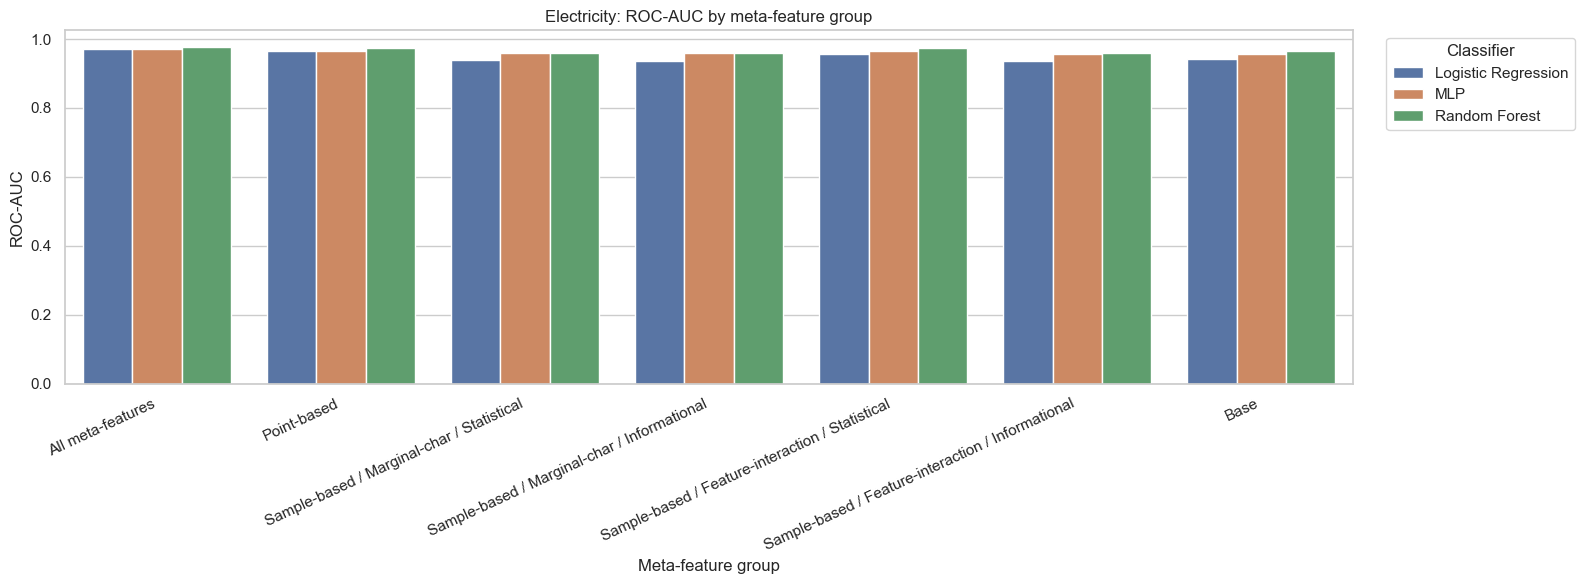

In [6]:
results_electricity = run_meta_significance_experiment('Electricity')
group_comparison_electricity = build_group_comparison_view(results_electricity)
group_table_electricity = build_group_metric_table(group_comparison_electricity)
show_dataset_summary('Electricity', results_electricity, group_comparison_electricity, group_table_electricity)


## Income Data

Dataset: Income


,group_name,n_meta_features,classifier,roc_auc,pr_auc,f1
0,All meta-features,37,Logistic Regression,0.9174,0.8228,0.7656
1,All meta-features,37,MLP,0.9025,0.7938,0.7397
2,All meta-features,37,Random Forest,0.9131,0.8010,0.7618
3,Point-based,8,Logistic Regression,0.8931,0.7841,0.7279
4,Point-based,8,MLP,0.8873,0.7664,0.7195
5,Point-based,8,Random Forest,0.8937,0.7744,0.7297
6,Sample-based / Marginal-char / Statistical,7,Logistic Regression,0.9175,0.8228,0.7649
7,Sample-based / Marginal-char / Statistical,7,MLP,0.8987,0.7809,0.7344
8,Sample-based / Marginal-char / Statistical,7,Random Forest,0.9041,0.7729,0.7538
9,Sample-based / Marginal-char / Informational,5,Logistic Regression,0.9081,0.8025,0.7515


,group_name,n_meta_features,f1 | Logistic Regression,f1 | MLP,f1 | Random Forest,pr_auc | Logistic Regression,pr_auc | MLP,pr_auc | Random Forest,roc_auc | Logistic Regression,roc_auc | MLP,roc_auc | Random Forest
0,All meta-features,37,0.7656,0.7397,0.7618,0.8228,0.7938,0.8010,0.9174,0.9025,0.9131
1,Point-based,8,0.7279,0.7195,0.7297,0.7841,0.7664,0.7744,0.8931,0.8873,0.8937
2,Sample-based / Marginal-char / Statistical,7,0.7649,0.7344,0.7538,0.8228,0.7809,0.7729,0.9175,0.8987,0.9041
3,Sample-based / Marginal-char / Informational,5,0.7515,0.7324,0.7537,0.8025,0.7880,0.7719,0.9081,0.9008,0.9037
4,Sample-based / Feature-interaction / Statistical,7,0.7614,0.7324,0.7578,0.8235,0.7918,0.7997,0.9171,0.9021,0.9125
5,Sample-based / Feature-interaction / Informati...,5,0.7696,0.7300,0.7517,0.8227,0.7753,0.7701,0.9180,0.8976,0.9033
6,Base,5,0.7479,0.7329,0.7505,0.8091,0.7916,0.7813,0.9088,0.9004,0.9056


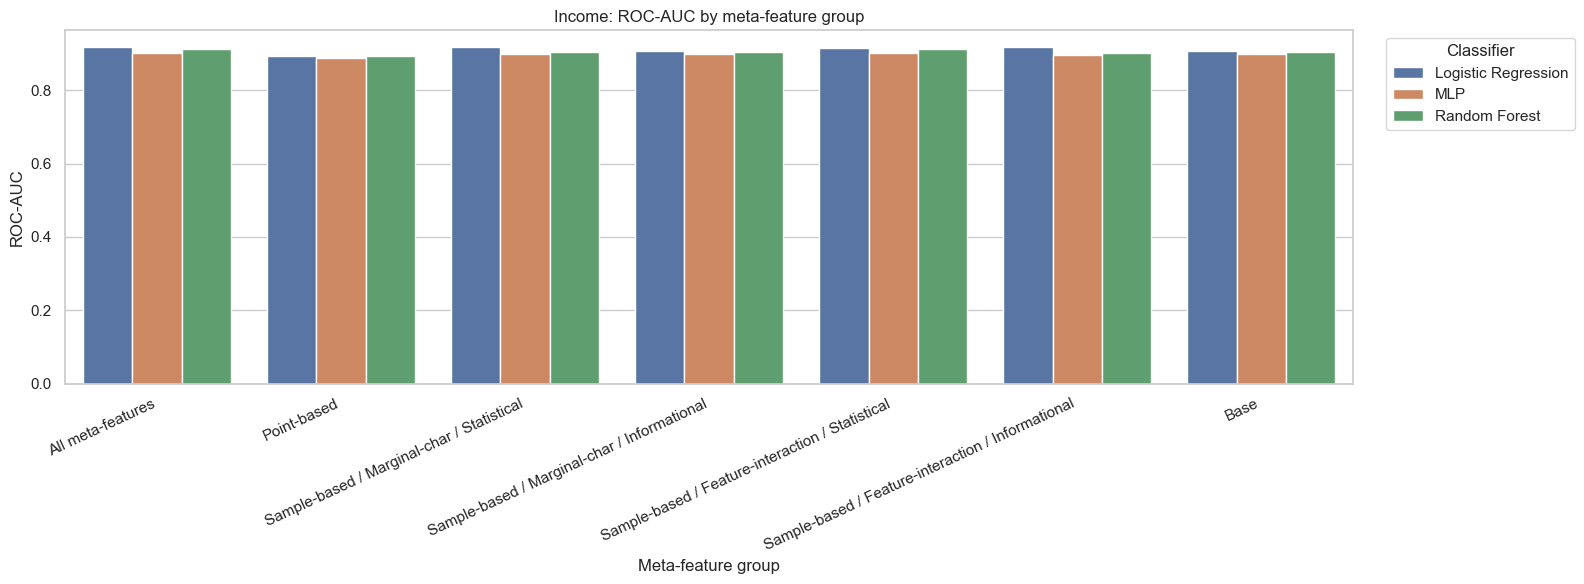

In [7]:
results_income = run_meta_significance_experiment('Income')
group_comparison_income = build_group_comparison_view(results_income)
group_table_income = build_group_metric_table(group_comparison_income)
show_dataset_summary('Income', results_income, group_comparison_income, group_table_income)


## MVx6 Data

Dataset: MVx6


,group_name,n_meta_features,classifier,roc_auc,pr_auc,f1
0,All meta-features,37,Logistic Regression,0.7846,0.8482,0.6861
1,All meta-features,37,MLP,0.7748,0.8345,0.6859
2,All meta-features,37,Random Forest,0.7880,0.8493,0.7058
3,Point-based,8,Logistic Regression,0.7844,0.8481,0.6855
4,Point-based,8,MLP,0.7722,0.8265,0.6819
5,Point-based,8,Random Forest,0.7874,0.8490,0.7031
6,Sample-based / Marginal-char / Statistical,7,Logistic Regression,0.7978,0.8563,0.7297
7,Sample-based / Marginal-char / Statistical,7,MLP,0.7812,0.8429,0.6956
8,Sample-based / Marginal-char / Statistical,7,Random Forest,0.7889,0.8498,0.7191
9,Sample-based / Marginal-char / Informational,5,Logistic Regression,0.7991,0.8570,0.7300


,group_name,n_meta_features,f1 | Logistic Regression,f1 | MLP,f1 | Random Forest,pr_auc | Logistic Regression,pr_auc | MLP,pr_auc | Random Forest,roc_auc | Logistic Regression,roc_auc | MLP,roc_auc | Random Forest
0,All meta-features,37,0.6861,0.6859,0.7058,0.8482,0.8345,0.8493,0.7846,0.7748,0.7880
1,Point-based,8,0.6855,0.6819,0.7031,0.8481,0.8265,0.8490,0.7844,0.7722,0.7874
2,Sample-based / Marginal-char / Statistical,7,0.7297,0.6956,0.7191,0.8563,0.8429,0.8498,0.7978,0.7812,0.7889
3,Sample-based / Marginal-char / Informational,5,0.7300,0.6972,0.7175,0.8570,0.8412,0.8493,0.7991,0.7796,0.7882
4,Sample-based / Feature-interaction / Statistical,7,0.7299,0.6994,0.7270,0.8569,0.8441,0.8513,0.7978,0.7832,0.7919
5,Sample-based / Feature-interaction / Informati...,5,0.7299,0.7013,0.7183,0.8557,0.8445,0.8507,0.7978,0.7826,0.7907
6,Base,5,0.7293,0.7009,0.7063,0.8537,0.8444,0.8453,0.7936,0.7826,0.7862


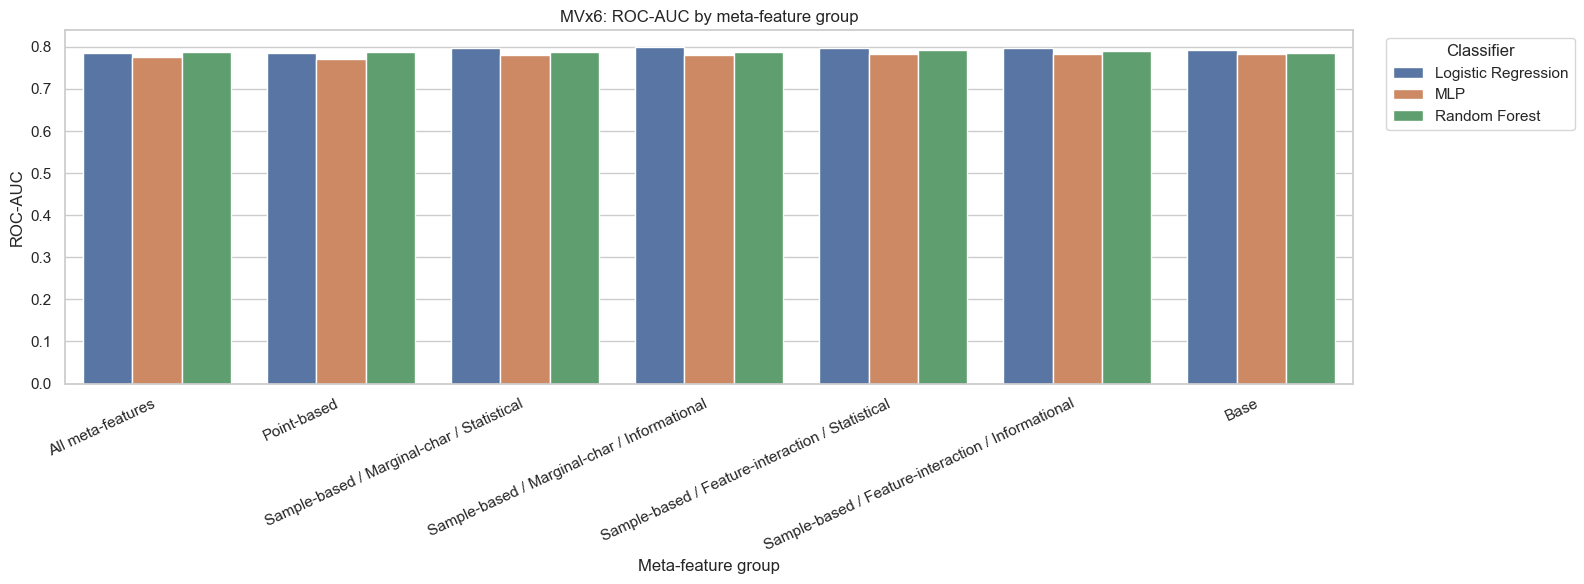

In [8]:
results_mvx6 = run_meta_significance_experiment('MVx6')
group_comparison_mvx6 = build_group_comparison_view(results_mvx6)
group_table_mvx6 = build_group_metric_table(group_comparison_mvx6)
show_dataset_summary('MVx6', results_mvx6, group_comparison_mvx6, group_table_mvx6)


## Diabetes Data

In [ ]:
results_diabetes = run_meta_significance_experiment('Diabetes')
group_comparison_diabetes = build_group_comparison_view(results_diabetes)
group_table_diabetes = build_group_metric_table(group_comparison_diabetes)
show_dataset_summary('Diabetes', results_diabetes, group_comparison_diabetes, group_table_diabetes)


## California Data

Dataset: California


,group_name,n_meta_features,classifier,roc_auc,pr_auc,f1
0,All meta-features,37,Logistic Regression,0.9901,0.9890,0.9500
1,All meta-features,37,MLP,0.9910,0.9908,0.9500
2,All meta-features,37,Random Forest,0.9938,0.9932,0.9578
3,Point-based,8,Logistic Regression,0.9864,0.9844,0.9429
4,Point-based,8,MLP,0.9828,0.9776,0.9369
5,Point-based,8,Random Forest,0.9925,0.9921,0.9549
6,Sample-based / Marginal-char / Statistical,7,Logistic Regression,0.9692,0.9526,0.9505
7,Sample-based / Marginal-char / Statistical,7,MLP,0.9615,0.9391,0.9206
8,Sample-based / Marginal-char / Statistical,7,Random Forest,0.9687,0.9500,0.9486
9,Sample-based / Marginal-char / Informational,5,Logistic Regression,0.9693,0.9513,0.9498


,group_name,n_meta_features,f1 | Logistic Regression,f1 | MLP,f1 | Random Forest,pr_auc | Logistic Regression,pr_auc | MLP,pr_auc | Random Forest,roc_auc | Logistic Regression,roc_auc | MLP,roc_auc | Random Forest
0,All meta-features,37,0.9500,0.9500,0.9578,0.9890,0.9908,0.9932,0.9901,0.9910,0.9938
1,Point-based,8,0.9429,0.9369,0.9549,0.9844,0.9776,0.9921,0.9864,0.9828,0.9925
2,Sample-based / Marginal-char / Statistical,7,0.9505,0.9206,0.9486,0.9526,0.9391,0.9500,0.9692,0.9615,0.9687
3,Sample-based / Marginal-char / Informational,5,0.9498,0.9286,0.9482,0.9513,0.9348,0.9471,0.9693,0.9615,0.9675
4,Sample-based / Feature-interaction / Statistical,7,0.9501,0.9433,0.9560,0.9715,0.9804,0.9874,0.9828,0.9840,0.9899
5,Sample-based / Feature-interaction / Informati...,5,0.9492,0.9277,0.9487,0.9515,0.9399,0.9499,0.9688,0.9625,0.9688
6,Base,5,0.9430,0.9415,0.9545,0.9712,0.9734,0.9800,0.9806,0.9813,0.9861


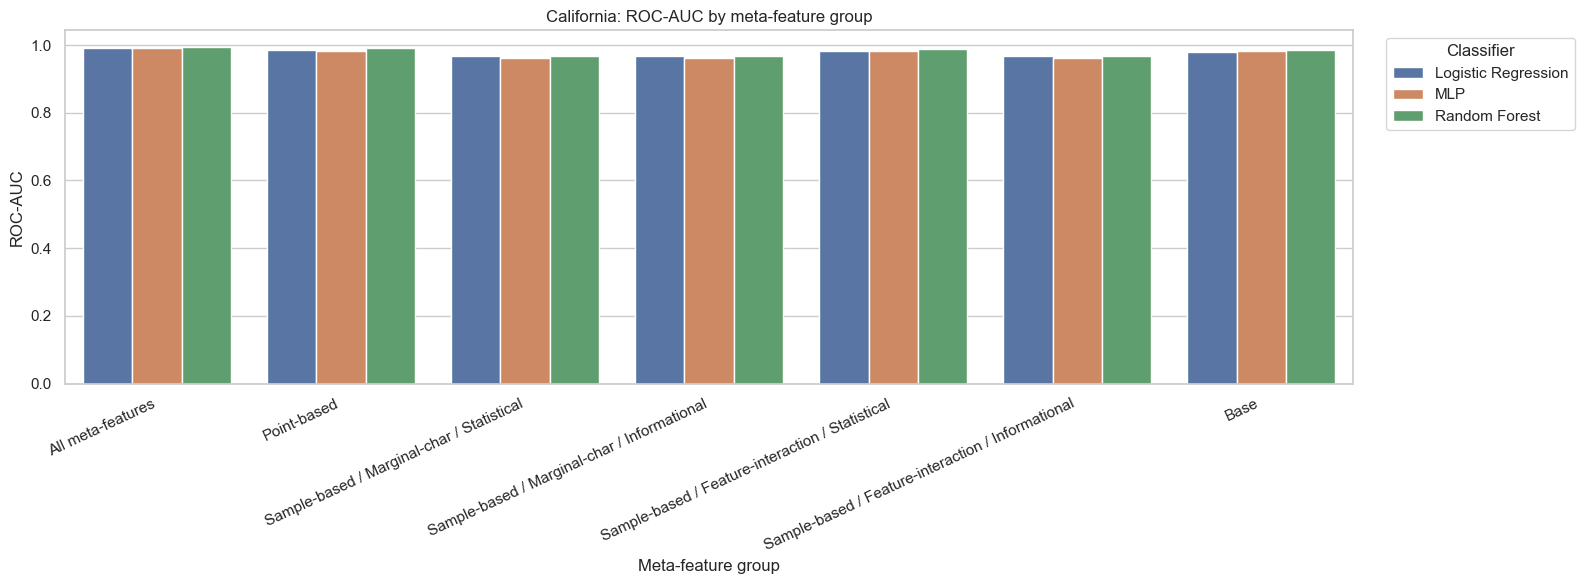

In [4]:
results_california = run_meta_significance_experiment('California')
group_comparison_california = build_group_comparison_view(results_california)
group_table_california = build_group_metric_table(group_comparison_california)
show_dataset_summary('California', results_california, group_comparison_california, group_table_california)


## ACS Accidents Data

Dataset: ACS Accidents


,group_name,n_meta_features,classifier,roc_auc,pr_auc,f1
0,All meta-features,37,Logistic Regression,1.0000,1.0000,0.9998
1,All meta-features,37,MLP,0.9995,0.9996,0.9996
2,All meta-features,37,Random Forest,1.0000,1.0000,1.0000
3,Point-based,8,Logistic Regression,0.9997,0.9998,0.9997
4,Point-based,8,MLP,0.9990,0.9991,0.9995
5,Point-based,8,Random Forest,1.0000,1.0000,1.0000
6,Sample-based / Marginal-char / Statistical,7,Logistic Regression,0.9631,0.8421,0.7067
7,Sample-based / Marginal-char / Statistical,7,MLP,0.9735,0.8965,0.8087
8,Sample-based / Marginal-char / Statistical,7,Random Forest,0.9717,0.8822,0.7960
9,Sample-based / Marginal-char / Informational,5,Logistic Regression,0.9435,0.7667,0.6514


,group_name,n_meta_features,f1 | Logistic Regression,f1 | MLP,f1 | Random Forest,pr_auc | Logistic Regression,pr_auc | MLP,pr_auc | Random Forest,roc_auc | Logistic Regression,roc_auc | MLP,roc_auc | Random Forest
0,All meta-features,37,0.9998,0.9996,1.0000,1.0000,0.9996,1.0000,1.0000,0.9995,1.0000
1,Point-based,8,0.9997,0.9995,1.0000,0.9998,0.9991,1.0000,0.9997,0.9990,1.0000
2,Sample-based / Marginal-char / Statistical,7,0.7067,0.8087,0.7960,0.8421,0.8965,0.8822,0.9631,0.9735,0.9717
3,Sample-based / Marginal-char / Informational,5,0.6514,0.7829,0.8017,0.7667,0.8732,0.8846,0.9435,0.9656,0.9724
4,Sample-based / Feature-interaction / Statistical,7,0.9014,0.9562,0.9648,0.9397,0.9870,0.9947,0.9902,0.9967,0.9991
5,Sample-based / Feature-interaction / Informati...,5,0.6615,0.7636,0.8010,0.7919,0.8525,0.8818,0.9483,0.9620,0.9717
6,Base,5,0.8312,0.9529,0.9424,0.9058,0.9903,0.9876,0.9815,0.9980,0.9978


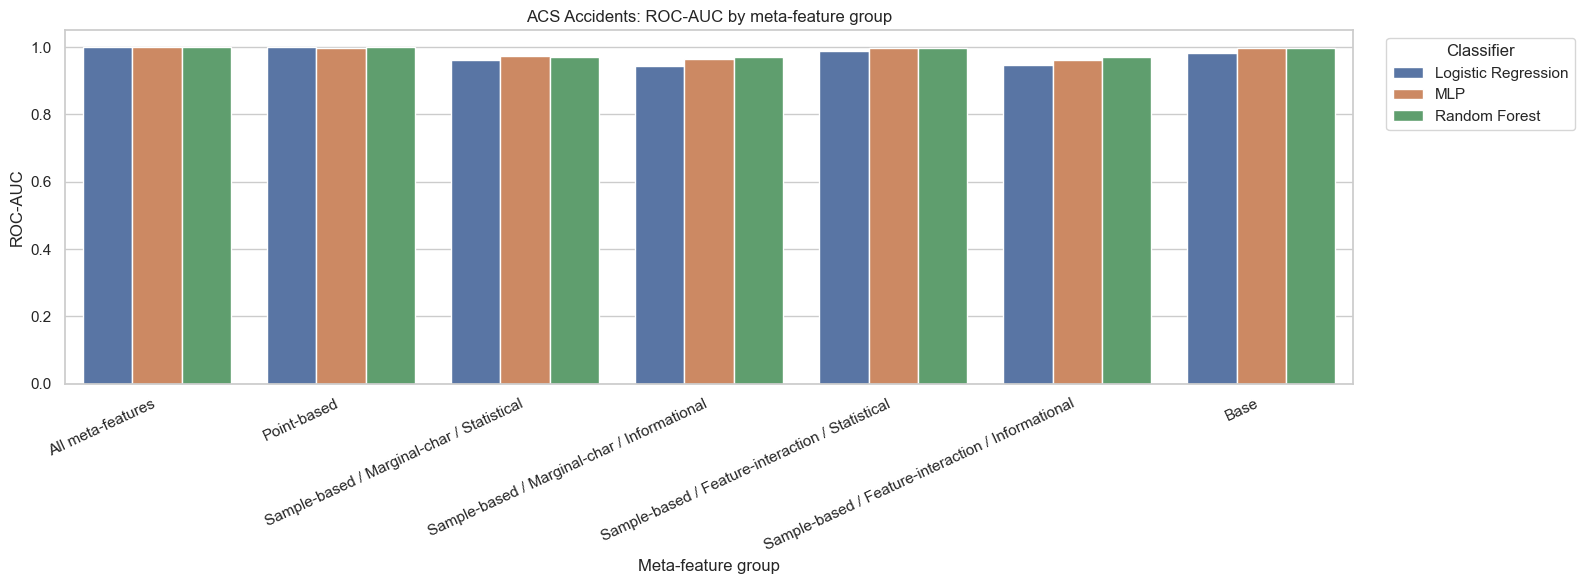

In [5]:
results_acs = run_meta_significance_experiment('ACS Accidents')
group_comparison_acs = build_group_comparison_view(results_acs)
group_table_acs = build_group_metric_table(group_comparison_acs)
show_dataset_summary('ACS Accidents', results_acs, group_comparison_acs, group_table_acs)
